# 01 - Exploratory Data Analysis

Two-level analysis:

1. **Transaction-level** - individual credit transactions
2. **Partner-level** - rolled up per business partner (the level the model scores)

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import hashlib
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded.")

Libraries loaded.


## 1. Load and clean raw data

In [2]:
df = pd.read_csv("../data/raw/business_partners.csv", low_memory=False)

for col in ["AmountInDisplayCurrency", "BalanceAmountInDisplayCurrency",
            "DebitAmountInDisplayCrcy", "CreditAmountInDisplayCrcy"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def parse_sap_date(val):
    try:
        ms = int(str(val).replace("/Date(", "").replace(")/", "").split("+")[0])
        return pd.Timestamp(ms, unit="ms")
    except:
        return pd.NaT

df["CANetDueDate"] = df["CANetDueDate"].apply(parse_sap_date)

def anonymize(name):
    if pd.isna(name) or str(name).strip() == "":
        return "CUSTOMER_UNKNOWN"
    return "CUSTOMER_" + hashlib.md5(str(name).encode()).hexdigest()[:6].upper()

df["BusinessPartnerName"] = df["BusinessPartnerName"].apply(anonymize)
df["FirstName"]  = "REDACTED"
df["LastName"]   = "REDACTED"
df["PostalCode"] = "REDACTED"

df["Amount"] = df["AmountInDisplayCurrency"].abs()

drop_cols = [
    "__metadata", "GeneratedId", "CAWorklistProcessingState",
    "CAWorklistProcessingStateText", "WorklistCreationDate", "CAGroupByKey",
    "Division", "BusinessArea", "CAAuthorizationGroup", "CASubApplication",
    "CAStatisticalItemCode", "CAContract", "ContractAccountCategory",
    "DisplayCurrency", "CARepetitionItemNumber", "CASubItemNumber", "WorklistCreationTime",
]
df = df.drop(columns=drop_cols, errors="ignore")

SEGMENT_LABELS = {"Z1": "Standard", "Z2": "Government", "Z3": "International", "Z4": "Corporate", "ZC": "Reversal"}
df["Segment"] = df["CAAccountDeterminationCode"].map(SEGMENT_LABELS).fillna("Unknown")

print("Shape:", df.shape)
print("Unique partners:", df["BusinessPartner"].nunique())
print("Date range:", df["CANetDueDate"].min(), "to", df["CANetDueDate"].max())

Shape: (264107, 21)
Unique partners: 11845
Date range: 2021-12-02 00:00:00 to 2026-06-21 00:00:00


## 2. Transaction-level EDA

### 2.1 Amount distribution

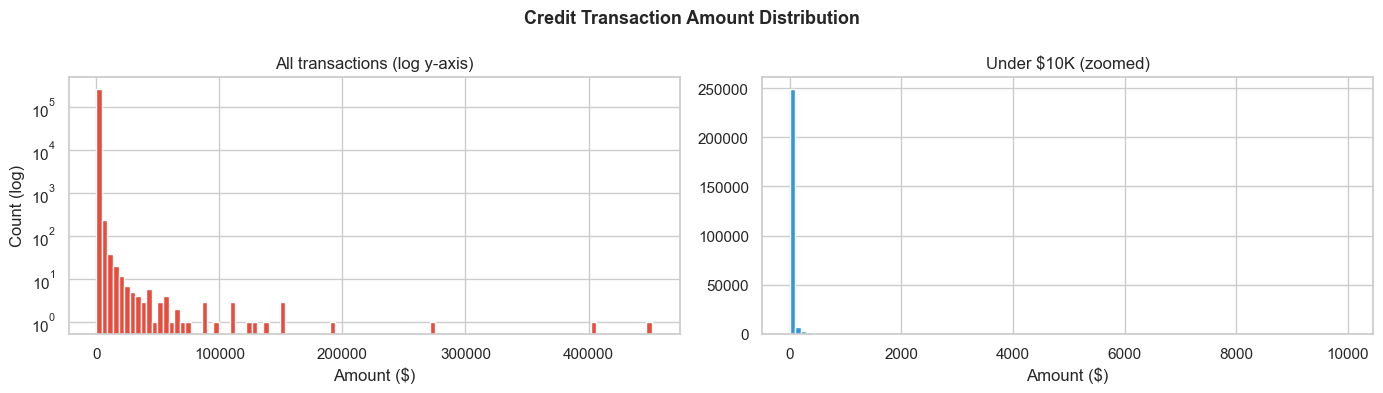

Largest single transaction: $451,636.78
Median transaction:         $6.32
Transactions over $10K:     115
Transactions over $100K:    13
99th percentile:            $629.69


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["Amount"].hist(bins=100, ax=axes[0], color="#e74c3c", edgecolor="white", log=True)
axes[0].set_title("All transactions (log y-axis)")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count (log)")

df[df["Amount"] < 10_000]["Amount"].hist(bins=100, ax=axes[1], color="#3498db", edgecolor="white")
axes[1].set_title("Under $10K (zoomed)")
axes[1].set_xlabel("Amount ($)")

plt.suptitle("Credit Transaction Amount Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

largest = df["Amount"].max()
median  = df["Amount"].median()
over10k = (df["Amount"] > 10_000).sum()
over100k = (df["Amount"] > 100_000).sum()
pct99 = df["Amount"].quantile(0.99)

print(f"Largest single transaction: ${largest:,.2f}")
print(f"Median transaction:         ${median:,.2f}")
print(f"Transactions over $10K:     {over10k:,}")
print(f"Transactions over $100K:    {over100k:,}")
print(f"99th percentile:            ${pct99:,.2f}")

### 2.2 Segment breakdown

Z1 (Standard) dominates at ~91% of transactions. This is why we score **within segment** -- a large Standard partner would drown out signals from smaller segments if scored globally.

               Transactions   TotalAmount  AvgAmount  UniquePartners  PctTransactions
Segment                                                                              
Standard             199555 12,694,525.83      63.61           11659            75.60
Corporate             60180  3,061,830.35      50.88             202            22.80
International          4277    135,445.04      31.67               6             1.60
Government               52     18,070.59     347.51              10             0.00
Reversal                 24     11,562.49     481.77               5             0.00
Unknown                  19     15,873.94     835.47              18             0.00


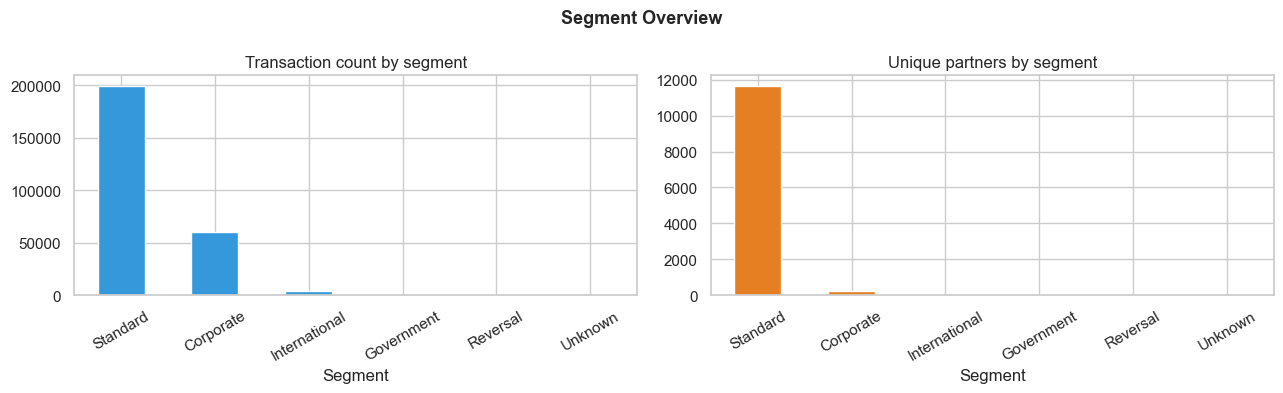

In [4]:
seg_stats = (
    df.groupby("Segment")
    .agg(
        Transactions=("Amount", "count"),
        TotalAmount=("Amount", "sum"),
        AvgAmount=("Amount", "mean"),
        UniquePartners=("BusinessPartner", "nunique"),
    )
    .sort_values("Transactions", ascending=False)
)
seg_stats["PctTransactions"] = (seg_stats["Transactions"] / seg_stats["Transactions"].sum() * 100).round(1)
print(seg_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
seg_stats["Transactions"].plot(kind="bar", ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Transaction count by segment")
axes[0].tick_params(axis="x", rotation=30)

seg_stats["UniquePartners"].plot(kind="bar", ax=axes[1], color="#e67e22", edgecolor="white")
axes[1].set_title("Unique partners by segment")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Segment Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Document type breakdown

`ZC` documents reverse `AC` credits. A high ZC/AC ratio per partner is a key fraud signal.

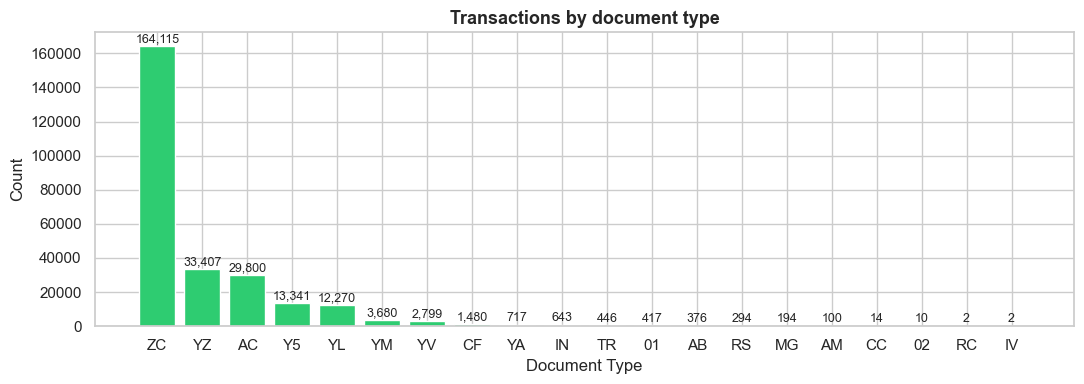

AC (credits):        29,800
ZC (reversals):      164,115
Global ZC/AC ratio:  5.51x  (partners well above this are suspect)


In [5]:
doc_counts = df["CADocumentType"].value_counts().reset_index()
doc_counts.columns = ["DocumentType", "Count"]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(doc_counts["DocumentType"], doc_counts["Count"], color="#2ecc71", edgecolor="white")
ax.set_title("Transactions by document type", fontsize=13, fontweight="bold")
ax.set_xlabel("Document Type")
ax.set_ylabel("Count")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

ac = (df["CADocumentType"] == "AC").sum()
zc = (df["CADocumentType"] == "ZC").sum()
ratio = zc / (ac + 1)
print(f"AC (credits):        {ac:,}")
print(f"ZC (reversals):      {zc:,}")
print(f"Global ZC/AC ratio:  {ratio:.2f}x  (partners well above this are suspect)")

### 2.4 Transactions over time

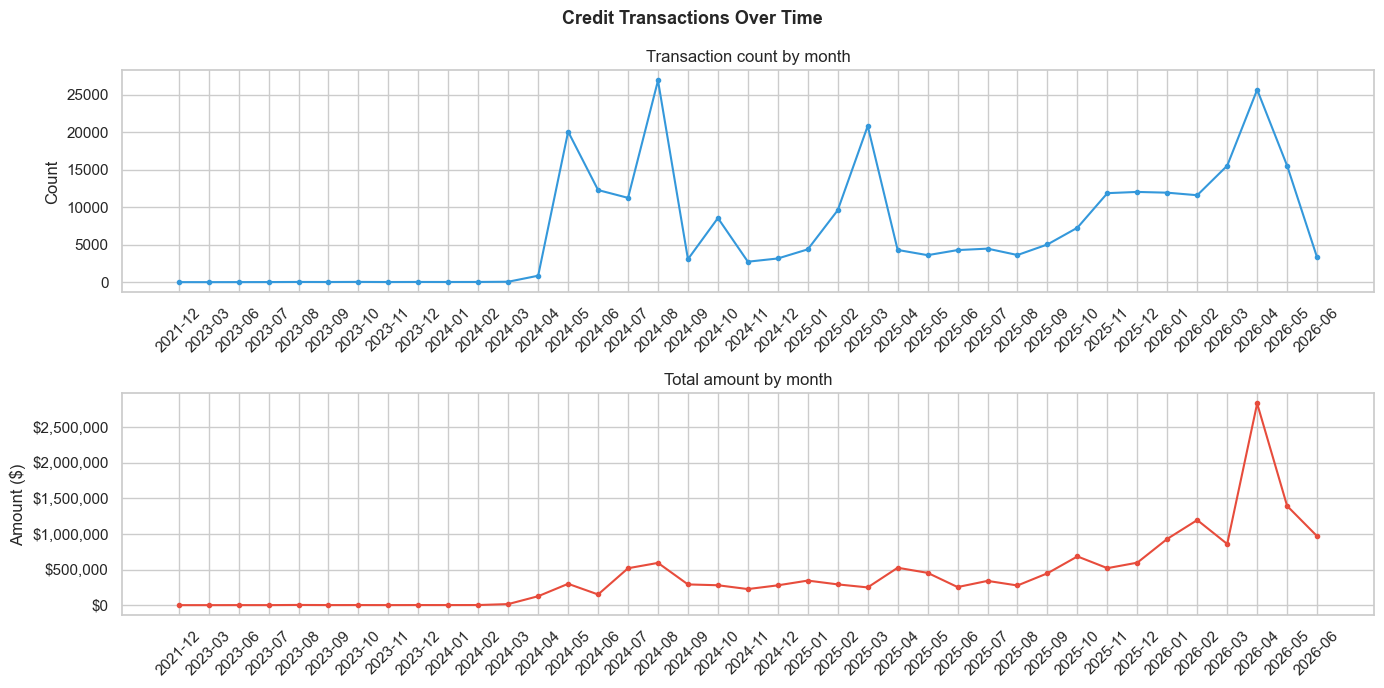

In [6]:
monthly = (
    df.groupby(df["CANetDueDate"].dt.to_period("M"))
    .agg(transaction_count=("Amount", "count"), total_amount=("Amount", "sum"))
    .reset_index()
    .sort_values("CANetDueDate")
)
monthly["CANetDueDate"] = monthly["CANetDueDate"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(monthly["CANetDueDate"], monthly["transaction_count"], color="#3498db", marker="o", markersize=3)
axes[0].set_title("Transaction count by month")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(monthly["CANetDueDate"], monthly["total_amount"], color="#e74c3c", marker="o", markersize=3)
axes[1].set_title("Total amount by month")
axes[1].set_ylabel("Amount ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(x)))
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Credit Transactions Over Time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Partner-level EDA

This section is the key addition over the original notebook. The anomaly models score partners, not individual transactions -- so we need to understand what the feature distributions look like **after aggregation**.

In [7]:
df["ACDocCount"]     = (df["CADocumentType"] == "AC").astype(int)
df["ZCDocCount"]     = (df["CADocumentType"] == "ZC").astype(int)
df["IsHighValue"]    = (df["Amount"] > 10_000).astype(int)
df["IsExtremeValue"] = (df["Amount"] > 100_000).astype(int)

partners = (
    df.groupby("BusinessPartner")
    .agg(
        BusinessPartnerName=("BusinessPartnerName", "first"),
        Segment=("Segment", "first"),
        TotalTransactions=("Amount", "count"),
        TotalAmount=("Amount", "sum"),
        AvgAmount=("Amount", "mean"),
        StdAmount=("Amount", "std"),
        MaxSingleAmount=("Amount", "max"),
        ACDocCount=("ACDocCount", "sum"),
        ZCDocCount=("ZCDocCount", "sum"),
        HighValueCount=("IsHighValue", "sum"),
        ExtremeValueCount=("IsExtremeValue", "sum"),
        Balance=("BalanceAmountInDisplayCurrency", "max"),
        TotalDebit=("DebitAmountInDisplayCrcy", "max"),
    )
    .reset_index()
    .fillna(0)
)

partners["ReversalRatio"]    = partners["ZCDocCount"] / (partners["ACDocCount"] + 1)
partners["AmountVolatility"] = partners["StdAmount"] / (partners["AvgAmount"] + 1)

print("Partner-level shape:", partners.shape)
print()
print("Segment counts:")
print(partners["Segment"].value_counts().to_string())

Partner-level shape: (11845, 16)

Segment counts:
Segment
Standard         11629
Corporate          190
Unknown             10
Government           9
International        5
Reversal             2


### 3.1 Feature distributions

Heavily right-skewed features are actually good for anomaly detection -- it means true outliers are far from the bulk of the data. But the skew also means we need `StandardScaler` before running Isolation Forest.

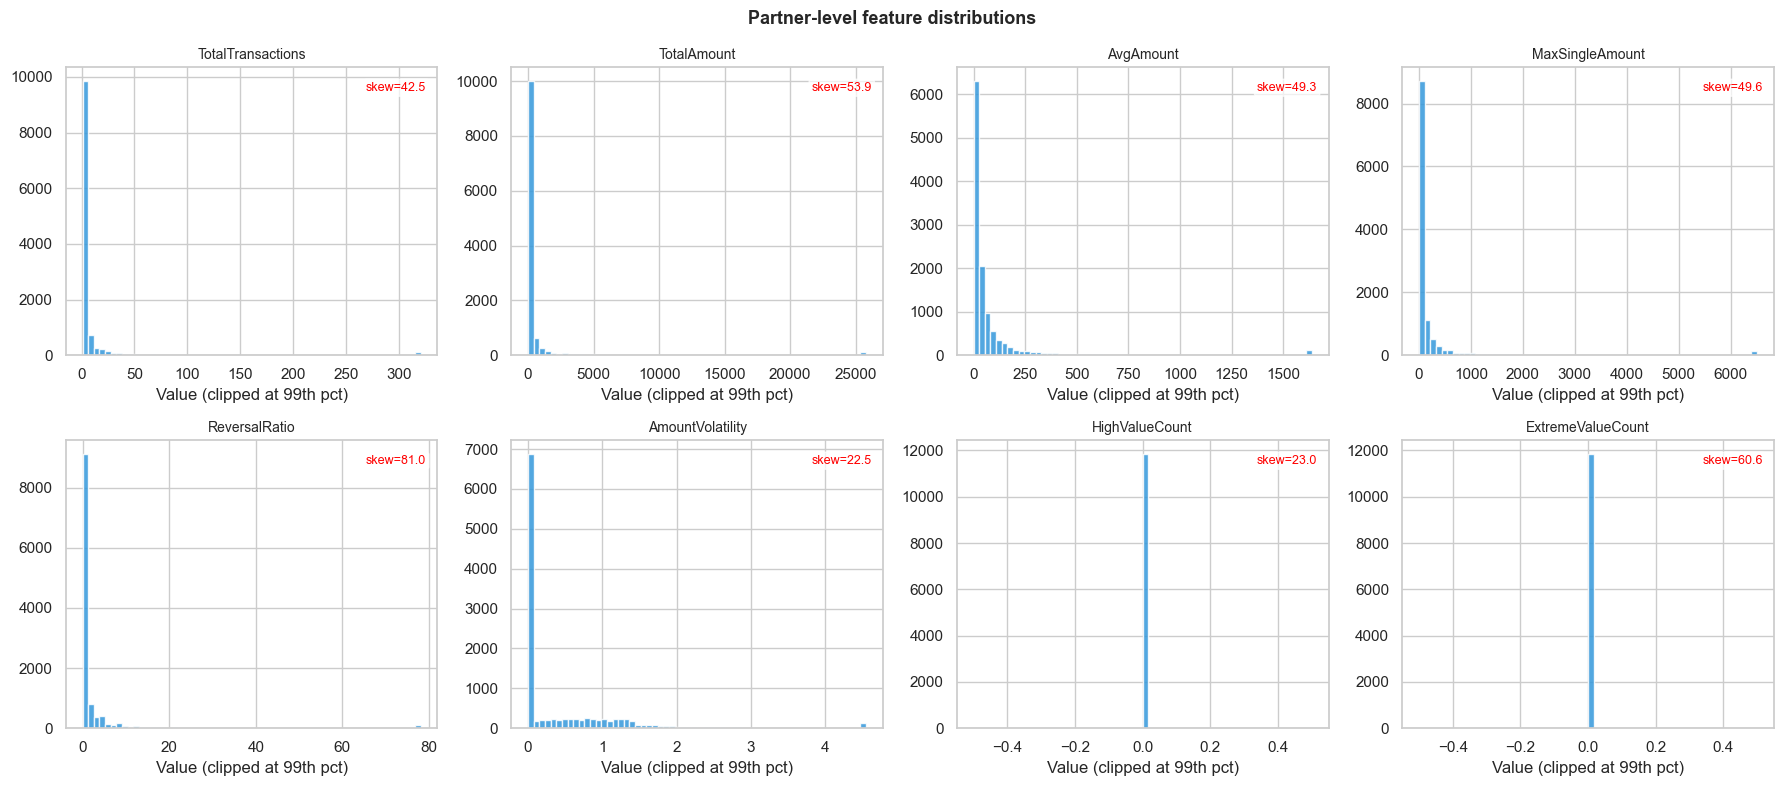

Skew summary (skew > 5 = strong outlier signal):
  TotalTransactions          skew:       42.5  <-- highly skewed
  TotalAmount                skew:       53.9  <-- highly skewed
  AvgAmount                  skew:       49.3  <-- highly skewed
  MaxSingleAmount            skew:       49.6  <-- highly skewed
  ReversalRatio              skew:       81.0  <-- highly skewed
  AmountVolatility           skew:       22.5  <-- highly skewed
  HighValueCount             skew:       23.0  <-- highly skewed
  ExtremeValueCount          skew:       60.6  <-- highly skewed


In [8]:
feature_cols = [
    "TotalTransactions", "TotalAmount", "AvgAmount", "MaxSingleAmount",
    "ReversalRatio", "AmountVolatility", "HighValueCount", "ExtremeValueCount",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = partners[col].clip(upper=partners[col].quantile(0.99))
    axes[i].hist(data, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Value (clipped at 99th pct)")
    skew = partners[col].skew()
    axes[i].text(0.97, 0.95, "skew={:.1f}".format(skew),
                 transform=axes[i].transAxes, ha="right", va="top", fontsize=9,
                 color="red", bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

plt.suptitle("Partner-level feature distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Skew summary (skew > 5 = strong outlier signal):")
for col in feature_cols:
    skew = partners[col].skew()
    flag = "  <-- highly skewed" if abs(skew) > 5 else ""
    print("  {:<25}  skew: {:>10.1f}{}".format(col, skew, flag))

### 3.2 Feature correlation matrix

Highly correlated features add redundant signal. If `TotalAmount` and `MaxSingleAmount` are 0.90 correlated, they're measuring nearly the same thing and that signal gets double-weighted in the model.

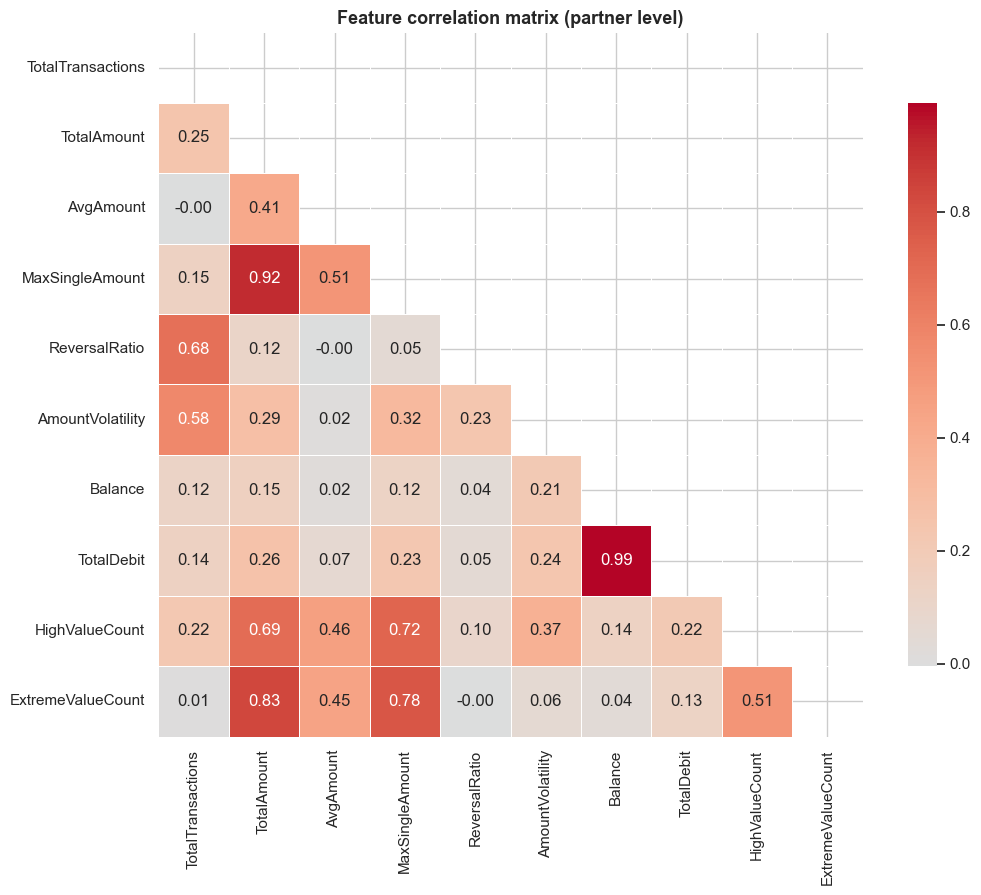

Highly correlated pairs (|r| > 0.7) -- overlapping signal in the model:
  TotalAmount               <-> MaxSingleAmount            r = 0.92
  TotalAmount               <-> ExtremeValueCount          r = 0.83
  MaxSingleAmount           <-> HighValueCount             r = 0.72
  MaxSingleAmount           <-> ExtremeValueCount          r = 0.78
  Balance                   <-> TotalDebit                 r = 0.99


In [9]:
corr_cols = [
    "TotalTransactions", "TotalAmount", "AvgAmount", "MaxSingleAmount",
    "ReversalRatio", "AmountVolatility", "Balance", "TotalDebit",
    "HighValueCount", "ExtremeValueCount",
]

corr = partners[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix (partner level)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|r| > 0.7) -- overlapping signal in the model:")
found = False
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print("  {:<25} <-> {:<25}  r = {:.2f}".format(corr_cols[i], corr_cols[j], r))
            found = True
if not found:
    print("  None above 0.7.")

### 3.3 Feature distributions by segment

If segment distributions differ, global scoring produces false positives. A `TotalAmount` that looks extreme in Government might be routine in Standard.

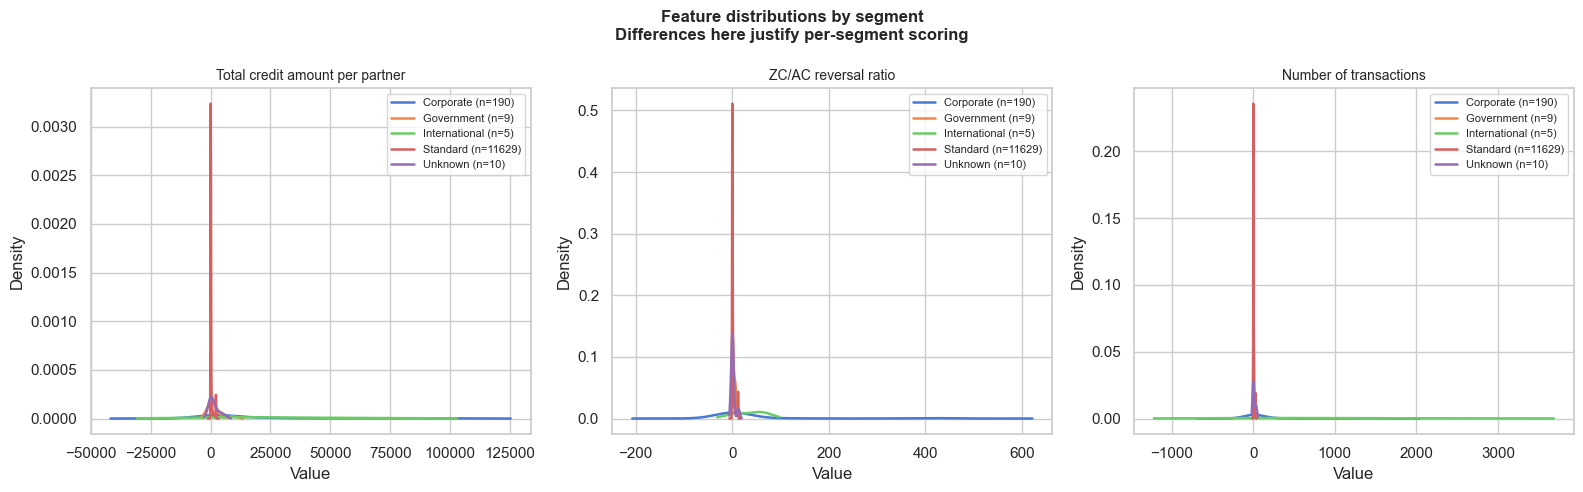

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_cols = [
    ("TotalAmount",      "Total credit amount per partner"),
    ("ReversalRatio",    "ZC/AC reversal ratio"),
    ("TotalTransactions","Number of transactions"),
]

for ax, (col, title) in zip(axes, plot_cols):
    for segment, grp in partners.groupby("Segment"):
        data = grp[col].clip(upper=grp[col].quantile(0.95))
        if len(data) >= 5:
            data.plot(kind="kde", ax=ax, label="{} (n={})".format(segment, len(grp)), linewidth=1.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Value")
    ax.legend(fontsize=8)

plt.suptitle("Feature distributions by segment\nDifferences here justify per-segment scoring", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 Top partners by key anomaly signals

In [11]:
def show_top(df, col, n=12):
    disp = ["BusinessPartnerName", "Segment", col, "TotalTransactions", "TotalAmount"]
    disp = [c for c in disp if c in df.columns]
    return df.nlargest(n, col)[disp].reset_index(drop=True)

print("=== Top 12 by ReversalRatio ===")
print(show_top(partners, "ReversalRatio").to_string())

print("\n=== Top 12 by MaxSingleAmount ===")
print(show_top(partners, "MaxSingleAmount").to_string())

print("\n=== Top 12 by TotalTransactions ===")
print(show_top(partners, "TotalTransactions").to_string())

=== Top 12 by ReversalRatio ===
   BusinessPartnerName    Segment  ReversalRatio  TotalTransactions  TotalAmount
0      CUSTOMER_230ED7   Standard      19,169.00              19174   123,630.86
1      CUSTOMER_6F1D98  Corporate       5,541.00               5549    11,373.89
2      CUSTOMER_590F96   Standard       5,051.00               5055   114,684.98
3      CUSTOMER_1A7575  Corporate       3,406.00               3416    79,502.45
4      CUSTOMER_2460EB  Corporate       2,888.67               8672    26,014.68
5      CUSTOMER_296FB5  Corporate       1,838.00               1874    63,166.76
6      CUSTOMER_CCB695   Standard       1,571.00               1579     6,240.67
7      CUSTOMER_A5E44D   Standard       1,389.00               1394    24,750.37
8      CUSTOMER_808404   Standard       1,132.00               1155   234,520.67
9      CUSTOMER_F7C53C  Corporate       1,042.00               1042    11,741.77
10     CUSTOMER_502ABA   Standard         934.00                934       828

### 3.5 EDA summary

In [13]:
sus_rev    = (partners["ReversalRatio"] > 5).sum()
ext_amount = (partners["MaxSingleAmount"] > 100_000).sum()
top1pct    = (partners["TotalTransactions"] > partners["TotalTransactions"].quantile(0.99)).sum()
ac_total   = (df["CADocumentType"] == "AC").sum()
zc_total   = (df["CADocumentType"] == "ZC").sum()

lines = [
    "=" * 60,
    "EDA SUMMARY - KEY FINDINGS",
    "=" * 60,
    "",
    "DATASET",
    "-------",
    "Total transactions:              {:>10,}".format(len(df)),
    "Unique business partners:        {:>10,}".format(len(partners)),
    "",
    "TRANSACTION-LEVEL SIGNALS",
    "--------------------------",
    "Largest single transaction:  ${:>12,.2f}".format(df["Amount"].max()),
    "Median transaction:          ${:>12,.2f}".format(df["Amount"].median()),
    "Transactions over $10K:          {:>10,}".format((df["Amount"] > 10_000).sum()),
    "Transactions over $100K:         {:>10,}".format((df["Amount"] > 100_000).sum()),
    "Global ZC/AC ratio:              {:>10.2f}x".format(zc_total / (ac_total + 1)),
    "",
    "PARTNER-LEVEL SIGNALS",
    "---------------------",
    "Partners with ReversalRatio > 5x:       {:>6,}".format(sus_rev),
    "Partners with MaxSingleAmount > $100K:  {:>6,}".format(ext_amount),
    "Partners in top 1pct by volume:         {:>6,}".format(top1pct),
    "Max ReversalRatio observed:             {:>6,.1f}x".format(partners["ReversalRatio"].max()),
    "",
    "SEGMENT BREAKDOWN",
    "-----------------",
    partners["Segment"].value_counts().to_string(),
    "",
    "MODELING NOTES",
    "--------------",
    "- TotalAmount and MaxSingleAmount are highly correlated -- overlapping signal",
    "- ReversalRatio is extremely right-skewed -- strong outlier signal",
    "- Segment distributions differ -- score within segment, not globally",
    "",
    "NEXT STEP: 02_features_and_model.ipynb",
]
print("\n".join(lines))

EDA SUMMARY - KEY FINDINGS

DATASET
-------
Total transactions:                 264,107
Unique business partners:            11,845

TRANSACTION-LEVEL SIGNALS
--------------------------
Largest single transaction:  $  451,636.78
Median transaction:          $        6.32
Transactions over $10K:                 115
Transactions over $100K:                 13
Global ZC/AC ratio:                    5.51x

PARTNER-LEVEL SIGNALS
---------------------
Partners with ReversalRatio > 5x:        1,127
Partners with MaxSingleAmount > $100K:       5
Partners in top 1pct by volume:            119
Max ReversalRatio observed:             19,169.0x

SEGMENT BREAKDOWN
-----------------
Segment
Standard         11629
Corporate          190
Unknown             10
Government           9
International        5
Reversal             2

MODELING NOTES
--------------
- TotalAmount and MaxSingleAmount are highly correlated -- overlapping signal
- ReversalRatio is extremely right-skewed -- strong outlier signal
